In [1]:
from easydict import EasyDict as edict
from rich import print, inspect
import datetime
import time
import json
from tqdm import tqdm
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

ModuleNotFoundError: No module named 'easydict'

In [6]:
def time_str_to_ts(time_str):
    import datetime
    dt = datetime.datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S")
    timestamp = int(dt.timestamp() *1000)
    return timestamp

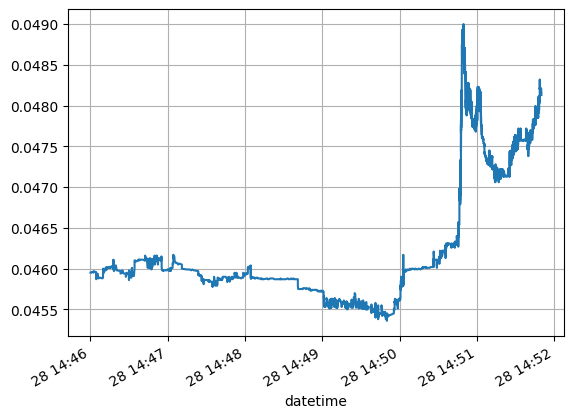

In [8]:
class Dataset(object):
    def __init__(self, trade_data_path, start_time = None, end_time = None) -> None:
        self.raw_trades = pd.read_csv(trade_data_path)
        self.symbol_name = self.raw_trades['symbol'][0]
        
        if start_time != None and end_time != None:
            self.start_time = start_time
            self.end_time = end_time
            self.handle_trades(self.start_time, self.end_time)
        else:
            self.trades = self.raw_trades
        
    def handle_trades(self, start_time = None, end_time = None):
        if start_time == None:
            start_time = self.start_time
        if end_time == None:
            end_time = self.end_time
        data = self.raw_trades
        self.trades = data[(data['timestamp']*1000 >= start_time) & (data['timestamp']*1000 <= end_time)] # ms
        return data

    def plot_trade(self):
        self.trades = self.trades.assign(datetime=pd.to_datetime(self.trades['timestamp'], unit='s'))

        self.trades.set_index('datetime',inplace=True)
        self.trades['price'].plot()
        plt.grid()


# data_path = 'trades/BRETTUSDT2024-05-26.csv'
# start_time = time_str_to_ts("2024-05-26 12:40:00")
# end_time = time_str_to_ts("2024-05-26 18:45:50")

data_path = '../trades/BRETTUSDT2024-04-28.csv'
start_time = time_str_to_ts("2024-04-28 22:46:00")
end_time = time_str_to_ts("2024-04-28 22:51:50")

dataset = Dataset(trade_data_path=data_path, start_time=start_time, end_time=end_time)
dataset.plot_trade()

In [2]:
class Order(object):
    def __init__(self, side:str) -> None:
        self.side = side
        self.cur_order_price = 0
        self.next_order_price = 0
        self.state_list = ['closed', 'active', 'closing', 'pending']
        self.state = "closed"
        
        self.post_delay = 0.02 # 20ms
        self.order_closing_start_ts = 0
        self.pending_order = None

    def init(self, market_price, spread, ticker_size):
        if self.side == 'sell':
            self.cur_order_price = market_price * (1 + spread)
            self.cur_order_price = int(self.cur_order_price * 1/ticker_size)*ticker_size+ticker_size
        else:
            self.cur_order_price = market_price * (1 - spread)
            self.cur_order_price = int(self.cur_order_price * 1/ticker_size)*ticker_size

        self.state = 'active'
        return self.cur_order_price
    
    def post_new_order(self, price, side, timestamp):
        self.pending_order = {'price': price, 'side': side, 'timestamp': timestamp}
        return self.pending_order
    
    def update_price(self, price):
        self.cur_order_price = price
        return self.cur_order_price
    
    def update_state(self, state):
        self.state = state
        return self.state

class BaseHfmmStrategy(object):
    def __init__(self, C) -> None:
        self.ticker_size = C.ticker_size
        self.ask_spreads = C.ask_spreads
        self.bid_spreads = C.bid_spreads
        self.ask_0_spread = C.ask_0_spread
        self.bid_0_spread = C.bid_0_spread
        self.order_size = C.order_size
        self.max_position = C.max_position
        self.position_edge_ratio = C.position_edge_ratio
        self.cancel_order_threshold = C.cancel_order_threshold
        self.close_cancel_order_threshold = C.close_cancel_order_threshold
        self.post_delay = C.post_delay
        
        self.ask_order = Order('sell')
        self.bid_order = Order('buy')
        

    def init_trades(self, trades):
        self.trades = trades
        self.trades_num = self.trades.shape[0]
        self.pre_trade = self.trades.iloc[0]
        
        self.position = 0
        self.my_trades = []
        self.my_orders = []
        
        return 
        
    def run(self, trades):
        self.init_trades(trades)
        self.ask_order.init(self.pre_trade['price'], self.ask_spreads, self.ticker_size)
        self.bid_order.init(self.pre_trade['price'], self.bid_spreads, self.ticker_size)

        # for id, trade in enumerate(self.trades):
        for id in tqdm(range(1, self.trades_num)):
            self.pre_trade = self.trades.iloc[id-1]
            self.cur_trade = self.trades.iloc[id]
            
            self.update_order_state()
            self.if_cancel_order()
            self.if_post_new_order()
        
        return 
    
    def update_order_state(self):
        self.if_activate_order()
        self.if_close_order()
        self.if_trade()
        return
    
    def if_trade(self):
        cur_market_price = self.cur_trade['price']
        if (self.ask_order.state == 'active' or self.ask_order.state == 'closing') :
            if (self.position > -self.max_position) and (self.ask_order.cur_order_price < cur_market_price):
                self.position -= self.order_size
                self.my_trades.append({'timestamp': self.cur_trade['timestamp'], 'entryprice': self.ask_order.cur_order_price, \
                                        'position': self.position, 'ordersize': self.order_size, 'side': 'sell'})
                self.ask_order.update_state('closed')
            
        if (self.bid_order.state == 'active' or self.bid_order.state == 'closing'):
            if (self.position < self.max_position) and (self.bid_order.cur_order_price > cur_market_price):
                self.position += self.order_size
                self.my_trades.append({'timestamp': self.cur_trade['timestamp'], 'entryprice': self.bid_order.cur_order_price, \
                                        'position': self.position, 'ordersize': self.order_size, 'side': 'buy'})
                self.bid_order.update_state('closed')
        
        return 
    
    def if_activate_order(self):
        cur_ts = self.cur_trade['timestamp']
        cur_market_price = self.cur_trade['price']
        
        if self.ask_order.state == 'pending':
            if cur_ts - self.ask_order.pending_order['timestamp'] >= self.post_delay:
                if cur_market_price < self.ask_order.pending_order['price']:
                    self.ask_order.update_price(self.ask_order.pending_order['price'])
                    self.ask_order.update_state('active')
                else:
                    self.ask_order.update_state('closed')
        
        if self.bid_order.state == 'pending':
            if cur_ts - self.bid_order.pending_order['timestamp'] >= self.post_delay:
                if cur_market_price > self.bid_order.pending_order['price']:
                    self.bid_order.update_price(self.bid_order.pending_order['price'])
                    self.bid_order.update_state('active')
                else:
                    self.bid_order.update_state('closed')
        return     
            
    def if_close_order(self):
        cur_ts = self.cur_trade['timestamp']
        if (cur_ts - self.ask_order.order_closing_start_ts >= self.post_delay) and (self.ask_order.state == 'closing'):
            self.ask_order.update_state('closed')
        if (cur_ts - self.bid_order.order_closing_start_ts >= self.post_delay) and (self.bid_order.state == 'closing'):
            self.bid_order.update_state('closed')
        return

    def if_cancel_order(self):
        cancel_threshold = self.cancel_order_threshold
        close_cancel_threshold = self.close_cancel_order_threshold
        
        if self.position >= 0:
            new_ask_price = self.get_close_order_price('sell')
            new_bid_price = self.get_open_order_price('buy')
            ask_price_change_ratio = abs(new_ask_price - self.ask_order.cur_order_price) / self.ask_order.cur_order_price
            bid_price_change_ratio = abs(new_bid_price - self.bid_order.cur_order_price) / self.bid_order.cur_order_price
            
            if (ask_price_change_ratio > close_cancel_threshold) and (self.ask_order.state == 'active'):
                self.ask_order.order_closing_start_ts = self.cur_trade['timestamp']
                self.ask_order.update_state('closing')
            if (bid_price_change_ratio > cancel_threshold) and (self.bid_order.state == 'active'):
                self.bid_order.order_closing_start_ts = self.cur_trade['timestamp']
                self.bid_order.update_state('closing')
                
        if self.position < 0:
            new_ask_price = self.get_open_order_price('sell')
            new_bid_price = self.get_close_order_price('buy')
            ask_price_change_ratio = abs(new_ask_price - self.ask_order.cur_order_price) / self.ask_order.cur_order_price
            bid_price_change_ratio = abs(new_bid_price - self.bid_order.cur_order_price) / self.bid_order.cur_order_price
            
            if (ask_price_change_ratio > cancel_threshold) and (self.ask_order.state == 'active'):
                self.ask_order.order_closing_start_ts = self.cur_trade['timestamp']
                self.ask_order.update_state('closing')
            if (bid_price_change_ratio > close_cancel_threshold) and (self.bid_order.state == 'active'):
                self.bid_order.order_closing_start_ts = self.cur_trade['timestamp']
                self.bid_order.update_state('closing')
        return
    
    
    def if_post_new_order(self):
        if self.ask_order.state == 'closed':
            self.post_new_ask_order()
            
        if self.bid_order.state == 'closed':
            self.post_new_bid_order()
        return

    def post_new_ask_order(self):
        if self.position > 0:
            new_ask_price = self.get_close_order_price('sell')
            self.ask_order.post_new_order(new_ask_price, 'sell', self.cur_trade['timestamp'])
            self.ask_order.update_state('pending')
        else:
            new_ask_price = self.get_open_order_price('sell')
            self.ask_order.post_new_order(new_ask_price, 'sell', self.cur_trade['timestamp']) 
            self.ask_order.update_state('pending')
        self.my_orders.append({'timestamp': self.cur_trade['timestamp'], 'price': new_ask_price, 'ordersize': self.order_size, 'side': 'sell'})
        return
    
    def post_new_bid_order(self):
        if self.position > 0:
            new_bid_price = self.get_open_order_price('buy')
            self.bid_order.post_new_order(new_bid_price, 'buy', self.cur_trade['timestamp'])
            self.bid_order.update_state('pending')
        else:
            new_bid_price = self.get_close_order_price('buy')
            self.bid_order.post_new_order(new_bid_price, 'buy', self.cur_trade['timestamp'])
            self.bid_order.update_state('pending')
        self.my_orders.append({'timestamp': self.cur_trade['timestamp'], 'price': new_bid_price, 'ordersize': self.order_size, 'side': 'buy'})
        return
    
    def get_open_order_price(self, side):
        position_num = abs(self.position / self.order_size)
        if side == 'sell':
            cur_ask_spreads = self.ask_spreads + position_num * self.position_edge_ratio + self.ask_0_spread
            new_ask_price = self.cur_trade['price'] * (1 + cur_ask_spreads)
            new_ask_price = int(new_ask_price* 1/self.ticker_size)*self.ticker_size+self.ticker_size
            return new_ask_price
        if side == 'buy':
            cur_bid_spreads = self.bid_spreads + position_num * self.position_edge_ratio + self.bid_0_spread
            new_bid_price = self.cur_trade['price'] * (1 - cur_bid_spreads)
            new_bid_price = int(new_bid_price* 1/self.ticker_size)*self.ticker_size
            return new_bid_price
        
    def get_close_order_price(self, side):
        # TODO 
        if side == 'sell':
            cur_ask_spreads = self.ask_spreads * (1 - abs(self.position) / self.max_position) + self.ask_0_spread
            new_ask_price = self.cur_trade['price'] * (1 + cur_ask_spreads)
            new_ask_price = int(new_ask_price* 1/self.ticker_size)*self.ticker_size+self.ticker_size
            return new_ask_price
        if side == 'buy':
            cur_bid_spreads = self.bid_spreads * (1 - abs(self.position) / self.max_position) + self.bid_0_spread
            new_bid_price = self.cur_trade['price'] * (1 - cur_bid_spreads)
            new_bid_price = int(new_bid_price* 1/self.ticker_size)*self.ticker_size
            return new_bid_price
    
    def get_trade_result(self):
        if len(self.my_trades) == 0:
            return 0
        pnl = 0
        tunrover = 0
        for id, trade in enumerate(self.my_trades):
            if trade['side'] == 'sell':
                pnl += trade['entryprice'] * trade['ordersize']
                tunrover += trade['entryprice'] * trade['ordersize']
            elif trade['side'] == 'buy':
                pnl -= trade['entryprice'] * trade['ordersize']
                tunrover += trade['entryprice'] * trade['ordersize']
            
            cur_pnl = pnl
            cur_turnover = tunrover
            if trade['position'] > 0:
                cur_pnl += trade['entryprice'] * trade['position']
                cur_turnover += trade['entryprice'] * trade['position']
            elif trade['position'] < 0:
                cur_pnl -= trade['entryprice'] * abs(trade['position'])
                cur_turnover += trade['entryprice'] * abs(trade['position'])
            
            self.my_trades[id]['pnl'] = cur_pnl
            self.my_trades[id]['tunrover'] = cur_turnover
            self.my_trades[id]['rot'] = cur_pnl / cur_turnover
            
        return 

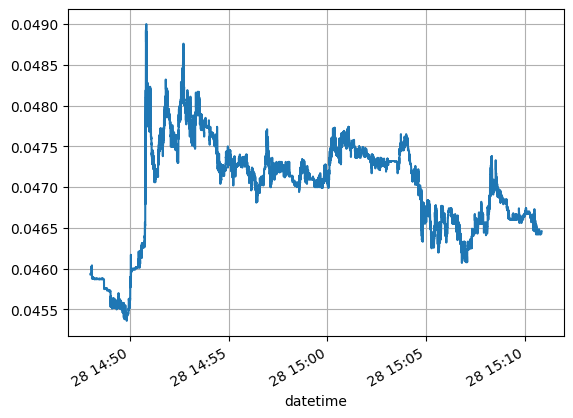

In [74]:
# data_path = 'trades/BRETTUSDT2024-05-26.csv'
# start_time = time_str_to_ts("2024-05-26 12:40:00")
# end_time = time_str_to_ts("2024-05-26 18:45:50")

data_path = 'trades/BRETTUSDT2024-04-28.csv'
start_time = time_str_to_ts("2024-04-28 22:48:00")
end_time = time_str_to_ts("2024-04-28 23:10:50")
dataset = Dataset(trade_data_path=data_path, start_time=start_time, end_time=end_time)
dataset.plot_trade()

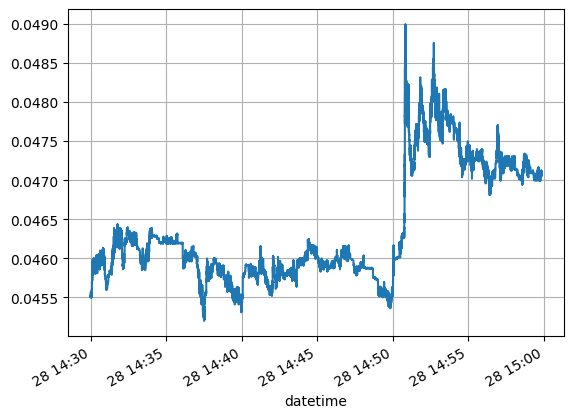

In [125]:
start_time = time_str_to_ts("2024-04-28 22:30:00")
end_time = time_str_to_ts("2024-04-28 22:59:50")
dataset.handle_trades(start_time, end_time)
dataset.plot_trade()

In [3]:
C = edict()
C.ticker_size = 0.00001
C.ask_spreads = 0.0015
C.bid_spreads = 0.0015
C.ask_0_spread = 0
C.bid_0_spread = 0
C.cancel_order_threshold = 0.00001
C.close_cancel_order_threshold = 0.0002
C.order_size = 1
C.max_position = 6
C.time_interval = 100
C.position_edge_ratio = 0.0005
C.post_delay = 0.02 # 20ms

C.trades = dataset.trades

s = BaseHfmmStrategy(C)
s.run(C.trades)
s.get_trade_result()
print(s.my_trades[-1])

NameError: name 'edict' is not defined

In [128]:
market_trades = dataset.trades
market_trades['datetime'] = pd.to_datetime(market_trades['timestamp'],unit='s')
market_trades.set_index('datetime',inplace=True)

In [129]:
my_trades = pd.DataFrame(s.my_trades)
my_trades['datetime'] = pd.to_datetime(my_trades['timestamp'],unit='s')
my_trades.loc[my_trades['side']=="sell", 'ordersize'] *= -1
my_trades['notional'] = my_trades['entryprice'] * my_trades['ordersize']
my_trades['pnl'] = -my_trades['notional'].cumsum() + my_trades['position'] * my_trades['entryprice']
my_trades.set_index('datetime',inplace=True)
my_trades

,timestamp,entryprice,position,ordersize,side,pnl,tunrover,rot,notional
datetime,,,,,,,,,
2024-04-28 14:30:04.417099953,1.714315e+09,0.04557,-1,-1,sell,0.00000,0.09114,0.000000,-0.04557
2024-04-28 14:30:06.896699905,1.714315e+09,0.04590,-2,-1,sell,-0.00033,0.18327,-0.001801,-0.04590
2024-04-28 14:30:07.037400007,1.714315e+09,0.04592,-3,-1,sell,-0.00037,0.27515,-0.001345,-0.04592
2024-04-28 14:30:16.164400101,1.714315e+09,0.04588,-2,1,buy,-0.00025,0.27503,-0.000909,0.04588
2024-04-28 14:30:26.593100071,1.714315e+09,0.04591,-1,1,buy,-0.00031,0.27509,-0.001127,0.04591
...,...,...,...,...,...,...,...,...,...
2024-04-28 14:58:03.735899925,1.714316e+09,0.04729,-2,-1,sell,-0.00590,8.71194,-0.000677,-0.04729
2024-04-28 14:58:04.100500107,1.714316e+09,0.04717,-1,1,buy,-0.00566,8.71170,-0.000650,0.04717
2024-04-28 14:58:34.765599966,1.714316e+09,0.04706,-2,-1,sell,-0.00555,8.80571,-0.000630,-0.04706


In [4]:
my_orders = pd.DataFrame(s.my_orders)
my_orders['datetime'] = pd.to_datetime(my_orders['timestamp'],unit='s')
my_orders.set_index('datetime',inplace=True)
my_bid_orders = my_orders[my_orders['side']=='buy']
my_ask_orders = my_orders[my_orders['side']=='sell']

result = pd.DataFrame(index=market_trades.resample('1s').last().index)
result['market_price'] = market_trades['price'].resample('1s').last().ffill()
result['bid_order_price'] = my_bid_orders['price'].resample('1s').last().ffill()
result['ask_order_price'] = my_ask_orders['price'].resample('1s').last().ffill()
result['bid_order_price'] = result['bid_order_price'].ffill()
result['ask_order_price'] = result['ask_order_price'].ffill()
result[['market_price','bid_order_price','ask_order_price']].plot(figsize=(15,6),grid=True, linewidth=1)

NameError: name 'pd' is not defined

In [131]:
result = pd.DataFrame(index=market_trades.resample('1s').last().index)
result['market_price'] = market_trades['price'].resample('1s').last().ffill()
result['position'] = my_trades['position'].resample('1s').last()
result['position'] = result['position'].ffill()
result['position'] = result['position'].fillna(0)
result['notional'] = my_trades['notional'].resample('1s').sum()
result['notional'] = result['notional'].fillna(0)
result['pnl'] = -result['notional'].cumsum() + result['position'] * result['market_price']
result

,market_price,position,notional,pnl
datetime,,,,
2024-04-28 14:30:00,0.04551,0.0,0.00000,0.00000
2024-04-28 14:30:01,0.04552,0.0,0.00000,0.00000
2024-04-28 14:30:02,0.04552,0.0,0.00000,0.00000
2024-04-28 14:30:03,0.04550,0.0,0.00000,0.00000
2024-04-28 14:30:04,0.04560,-1.0,-0.04557,-0.00003
...,...,...,...,...
2024-04-28 14:59:45,0.04708,-4.0,0.00000,-0.00529
2024-04-28 14:59:46,0.04708,-4.0,0.00000,-0.00529
2024-04-28 14:59:47,0.04708,-4.0,0.00000,-0.00529


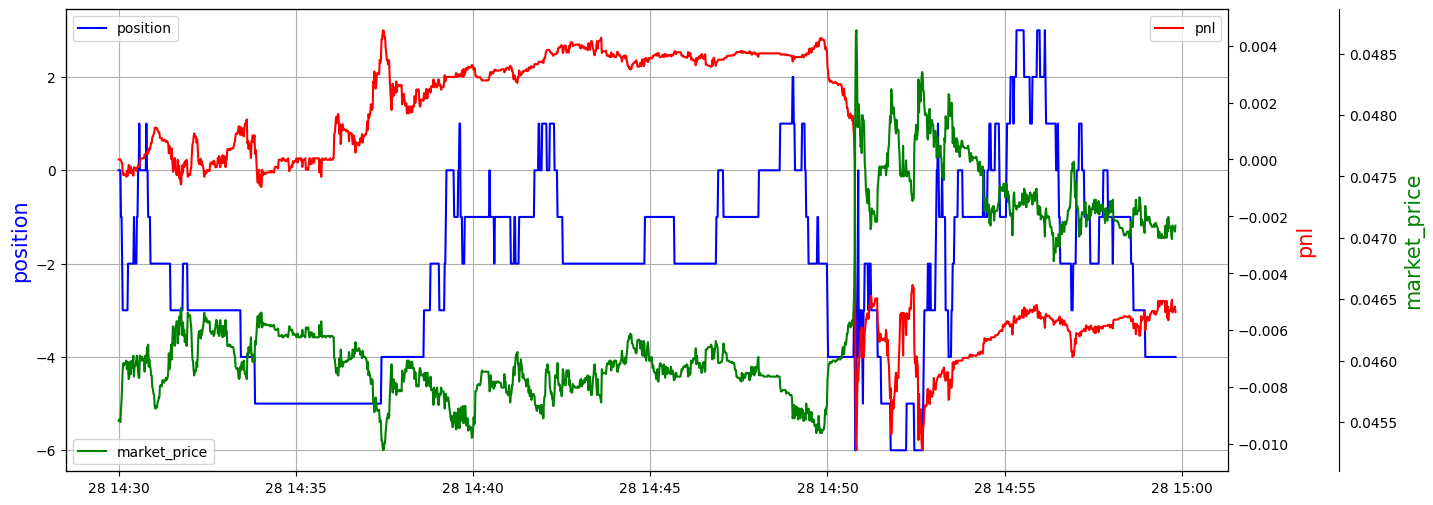

In [132]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(result.index, result['position'], color='blue')

ax2 = ax1.twinx()
ax2.plot(result.index, result['pnl'], color='red')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 80))
ax3.plot(result.index, result['market_price'], color='green')

# legend
ax1.legend(['position'], loc='upper left')
ax2.legend(['pnl'], loc='upper right')
ax3.legend(['market_price'], loc='lower left')

# label
ax1.set_ylabel('position', color='blue', size=15)
ax2.set_ylabel('pnl', color='red', size=15)
ax3.set_ylabel('market_price', color='green', size=15)

ax1.grid()
# plt.grid()
plt.show()

# result[['pnl','position']].plot(figsize=(15,6),grid=True)